# Task 4

## Task: Banknote Authentication Classification

In this task, you will work with the dataset provided in the file **`data_banknote_authentication.csv`**

Your objective is to build and evaluate classification models to predict the authenticity of banknotes.

You should:

- Load and explore the dataset.
- Build two classification models:
  - **Decision Tree**
  - **Random Forest**
- Use **GridSearchCV** to optimize the hyperparameters of each model.
- Evaluate the performance of both models using:
  - **Confusion Matrix**
  - **Classification Report**

Finally, **compare the performance of the two models** and discuss which model performs better for this dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Exploring Dataset

In [2]:
df = pd.read_csv('data_banknote_authentication.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Variance_Wavelet  1372 non-null   float64
 1   Skewness_Wavelet  1372 non-null   float64
 2   Curtosis_Wavelet  1372 non-null   float64
 3   Image_Entropy     1372 non-null   float64
 4   Class             1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [3]:
df.describe()

,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [4]:
df.isnull().sum()

Variance_Wavelet    0
Skewness_Wavelet    0
Curtosis_Wavelet    0
Image_Entropy       0
Class               0
dtype: int64

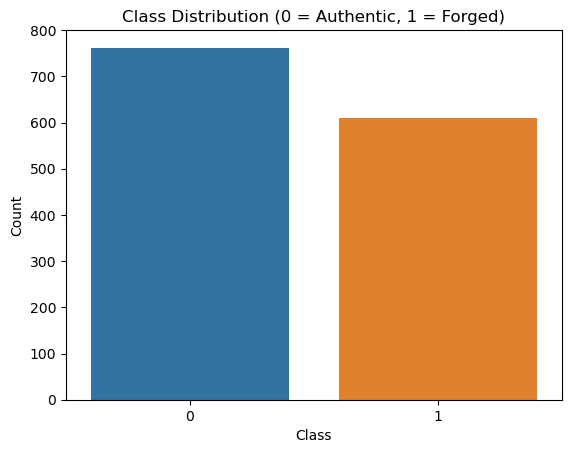

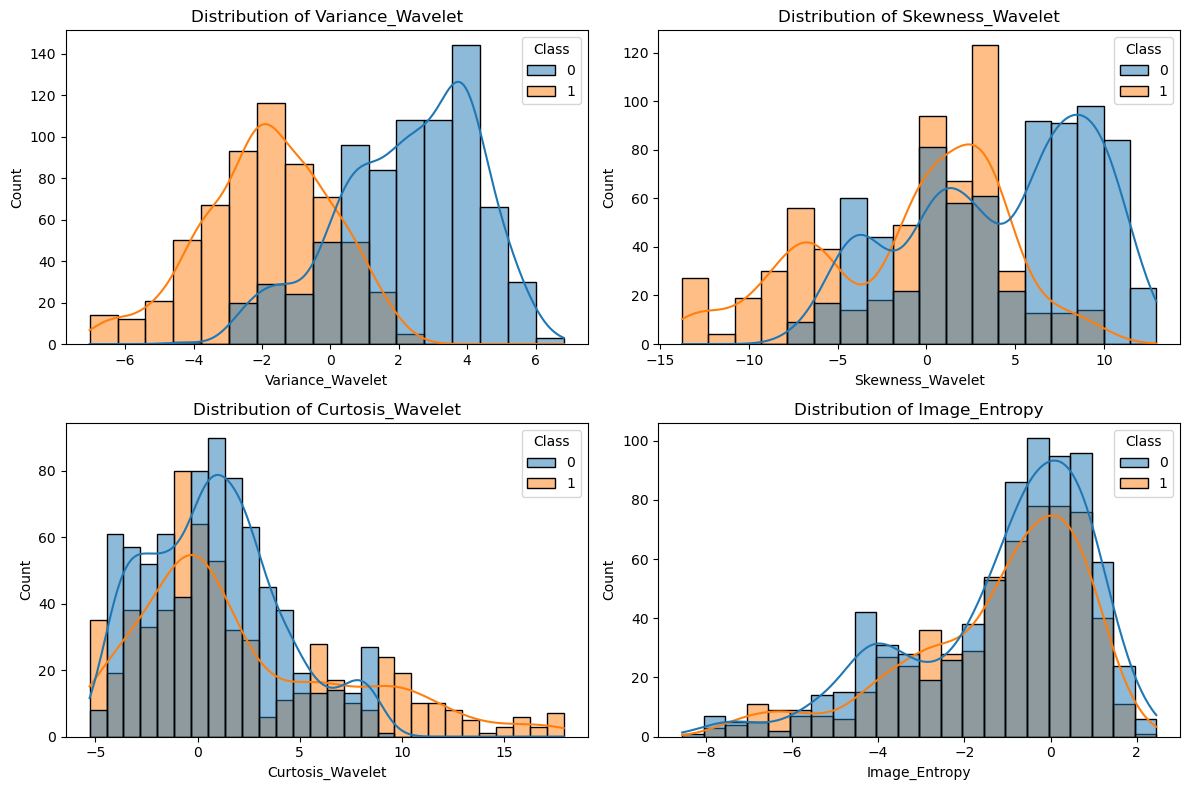

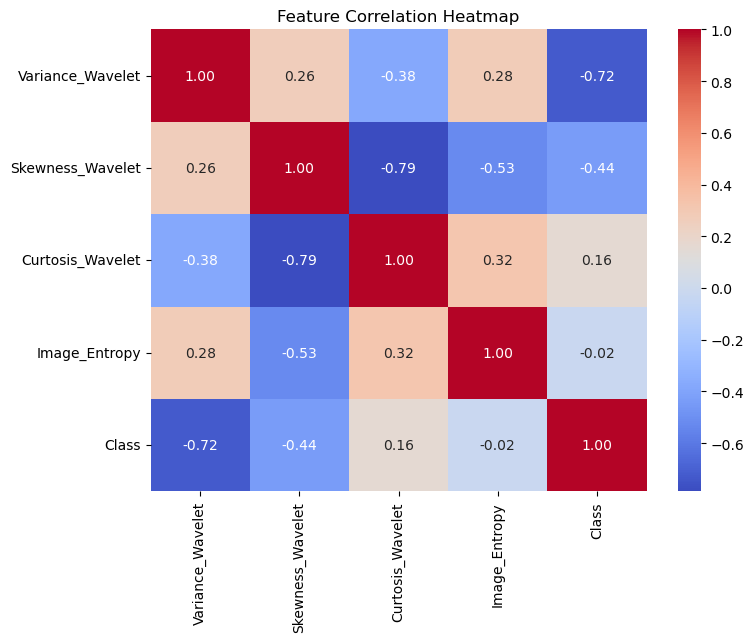

In [10]:
# Check class distribution
df['Class'].value_counts()

# Visualize class distribution
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0 = Authentic, 1 = Forged)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

# Visualize feature distributions by class
features = ['Variance_Wavelet', 'Skewness_Wavelet', 'Curtosis_Wavelet', 'Image_Entropy']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(data=df, x=feature, hue='Class', kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()



## Train and Test

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

print(f'Training set size: {X_train.shape[0]}')
print(f'Test set size:     {X_test.shape[0]}')

Training set size: 960
Test set size:     412


## Decision Tree Classification

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [14]:
dt_model = DecisionTreeClassifier(random_state=101)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

**GridSearchCV**

In [15]:
param_grid_dt = {
    'criterion':         ['gini', 'entropy'],
    'max_depth':         [None, 3, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4]
}

grid_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=101),
    param_grid=param_grid_dt,
    cv=5,
    scoring='accuracy',
    verbose=1
)

grid_dt.fit(X_train, y_train)

print('Best Parameters (Decision Tree):')
print(grid_dt.best_params_)
print(f'\nBest Cross-Validation Accuracy: {grid_dt.best_score_:.4f}')

best_dt = grid_dt.best_estimator_
y_pred_best_dt = best_dt.predict(X_test)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters (Decision Tree):
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Cross-Validation Accuracy: 0.9896


**Evaluation of Decision Tree Classification**

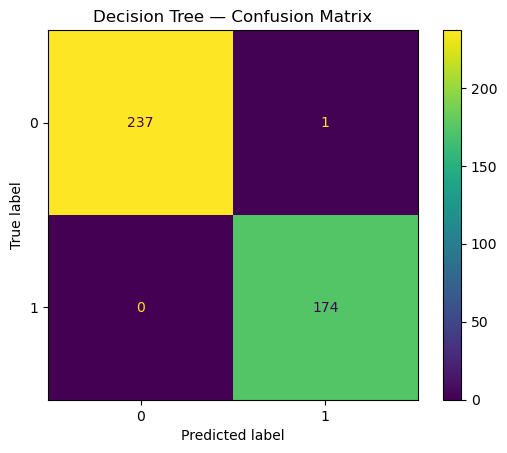

Decision Tree — Classification Report
               precision    recall  f1-score   support

Authentic (0)       1.00      1.00      1.00       238
   Forged (1)       0.99      1.00      1.00       174

     accuracy                           1.00       412
    macro avg       1.00      1.00      1.00       412
 weighted avg       1.00      1.00      1.00       412



In [16]:
# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(best_dt, X_test, y_test)
plt.title('Decision Tree — Confusion Matrix')
plt.show()

# Classification Report
print('Decision Tree — Classification Report')
print('=' * 45)
print(classification_report(y_test, y_pred_best_dt, target_names=['Authentic (0)', 'Forged (1)']))

## Random Forest Classification

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=101)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

**GridSearchCV**

In [18]:
param_grid_rf = {
    'n_estimators':      [50, 100, 200],
    'max_depth':         [None, 5, 10, 20],
    'max_features':      ['sqrt', 'log2'],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=101),
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    verbose=1
)

grid_rf.fit(X_train, y_train)

print('Best Parameters (Random Forest):')
print(grid_rf.best_params_)
print(f'\nBest Cross-Validation Accuracy: {grid_rf.best_score_:.4f}')

best_rf = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best Parameters (Random Forest):
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}

Best Cross-Validation Accuracy: 0.9948


**Evaluation of Random Forest Classification**

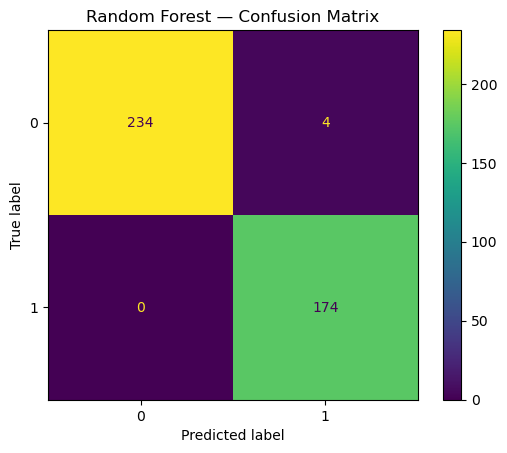

Random Forest — Classification Report
               precision    recall  f1-score   support

Authentic (0)       1.00      0.98      0.99       238
   Forged (1)       0.98      1.00      0.99       174

     accuracy                           0.99       412
    macro avg       0.99      0.99      0.99       412
 weighted avg       0.99      0.99      0.99       412



In [19]:
# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test)
plt.title('Random Forest — Confusion Matrix')
plt.show()

# Classification Report
print('Random Forest — Classification Report')
print('=' * 45)
print(classification_report(y_test, y_pred_best_rf, target_names=['Authentic (0)', 'Forged (1)']))

**Feature Importance**

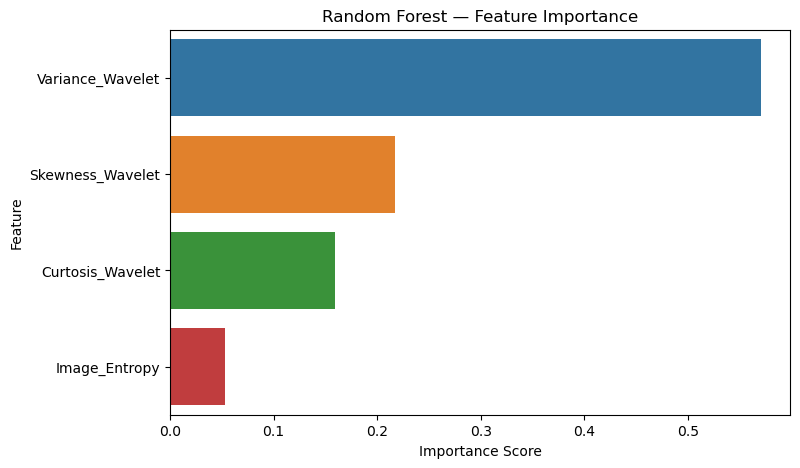

In [20]:
feature_importances = pd.Series(best_rf.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importances.values, y=feature_importances.index)
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

## Model Comparison

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = {
    'Model':     ['Decision Tree', 'Random Forest'],
    'Accuracy':  [accuracy_score(y_test, y_pred_best_dt),  accuracy_score(y_test, y_pred_best_rf)],
    'Precision': [precision_score(y_test, y_pred_best_dt), precision_score(y_test, y_pred_best_rf)],
    'Recall':    [recall_score(y_test, y_pred_best_dt),    recall_score(y_test, y_pred_best_rf)],
    'F1-Score':  [f1_score(y_test, y_pred_best_dt),        f1_score(y_test, y_pred_best_rf)]
}

comparison_df = pd.DataFrame(metrics).set_index('Model').round(4)
comparison_df

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Decision Tree,0.9976,0.9943,1.0,0.9971
Random Forest,0.9903,0.9775,1.0,0.9886


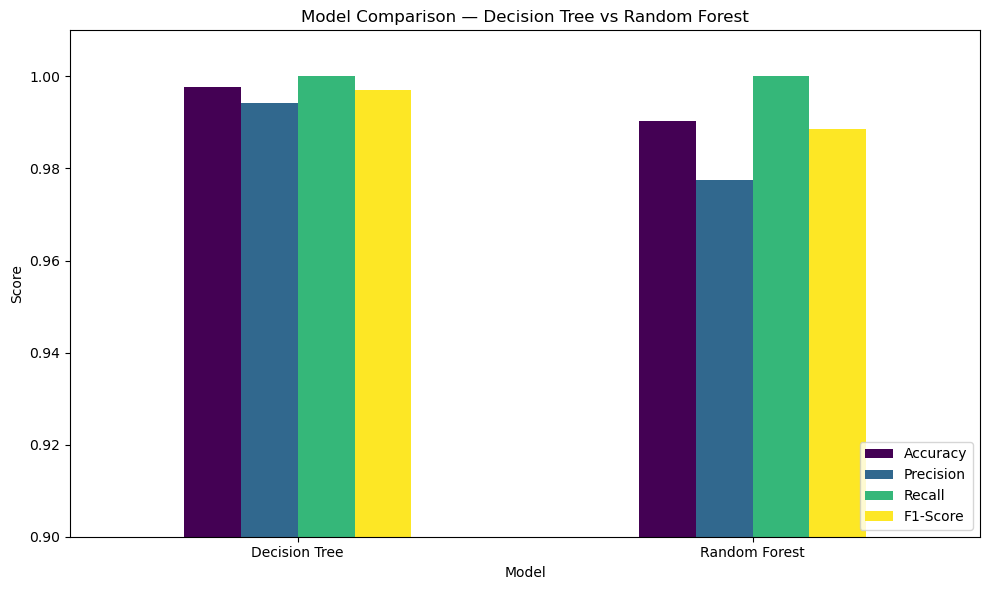

In [22]:
# Bar chart comparison
comparison_df.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('Model Comparison — Decision Tree vs Random Forest')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0.9, 1.01)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

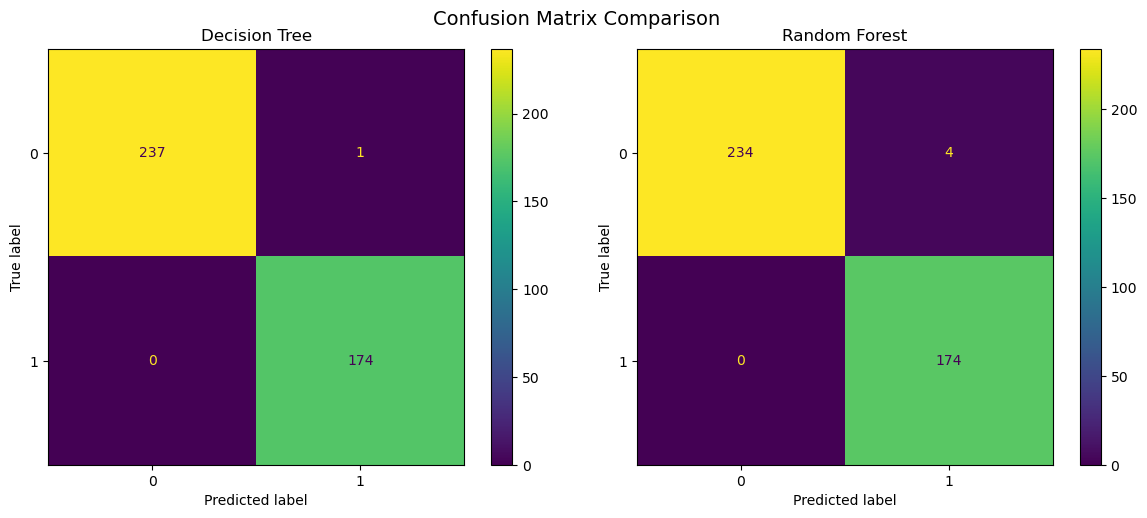

In [23]:
# Side-by-side Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(best_dt, X_test, y_test, ax=axes[0])
axes[0].set_title('Decision Tree')

ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test, ax=axes[1])
axes[1].set_title('Random Forest')

plt.suptitle('Confusion Matrix Comparison', fontsize=14)
plt.tight_layout()
plt.show()

## Which model performs better on this dataset?

Both models performed exceptionally well on the Banknote Authentication dataset, achieving near-perfect scores across all metrics. Looking at the test set results, the Decision Tree slightly outperformed Random Forest with an accuracy of 99.76% compared to 99.03%, along with higher precision (0.9943 vs 0.9775) and F1-score (0.9971 vs 0.9886), while both models achieved a perfect recall of 1.00, meaning neither model missed a single forged banknote. However, when looking at cross validation accuracy, Random Forest scored higher (0.9948 vs 0.9896), which means it generalized more consistently across different subsets of the data.

The reason the Decision Tree performed so well on the test set comes down to the nature of this dataset. The wavelet-transformed features are highly discriminative and produce a clean, well-separated decision boundary between authentic and forged banknotes, which means a single tree can learn the pattern almost perfectly without needing the support of an ensemble. The best parameters found by GridSearchCV allowed the Decision Tree to grow fully with no depth limit, capturing these boundaries with very few errors.

Despite the Decision Tree winning on the test set, Random Forest remains the more trustworthy model overall. A fully grown Decision Tree with no max depth is highly prone to overfitting, meaning it memorizes the training data rather than truly learning generalizable patterns, and its strong test performance may simply be a result of the particular random split used. Random Forest overcomes this weakness by building many trees on different random subsets of the data and combining their predictions, which reduces variance and produces more stable results. This is confirmed by its higher cross-validation accuracy, which is a more reliable indicator of real-world performance than a single test set evaluation. Therefore, while the Decision Tree achieved a slightly better score in this experiment, Random Forest is the better choice for deploying a banknote authentication system in practice, as it is more robust, less sensitive to data variations, and more likely to maintain its performance on new, unseen banknotes.